In [ ]:
# 加载环境变量并设置自动重载
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

# 研究智能体

*研究的目标是收集研究概要所要求的上下文信息。*

这是我们整体的研究流程：

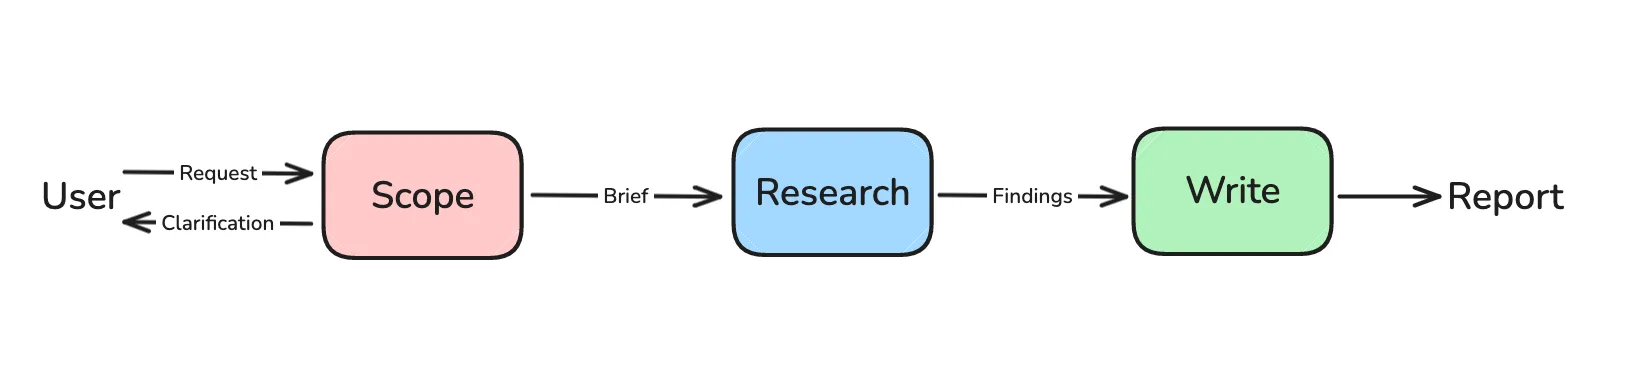

研究是一个开放性的任务。回答用户请求的最佳策略无法提前轻易确定。

请求可能需要不同的研究策略和不同的搜索深度。考虑这个请求：

> *"比较这两个产品"*

比较通常受益于对每个产品的搜索，然后进行综合步骤来比较它们。现在，考虑这个请求：

> *"给我列出我的职位发布的顶级候选人"*

列表和排名请求通常需要开放性搜索，然后进行综合和排名。
 
[智能体](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent)非常适合研究，因为它们可以灵活地应用不同的策略，使用中间结果来指导它们的探索。

智能体遵循一个[简单而有效的模式](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent)：

1. **LLM决策节点**：分析当前状态并决定是进行工具调用还是提供最终响应
2. **工具执行节点**：当LLM确定需要更多信息时执行搜索工具
3. **研究压缩节点**：总结和压缩研究发现以便高效处理
4. **路由逻辑**：根据LLM的决策确定工作流程的继续

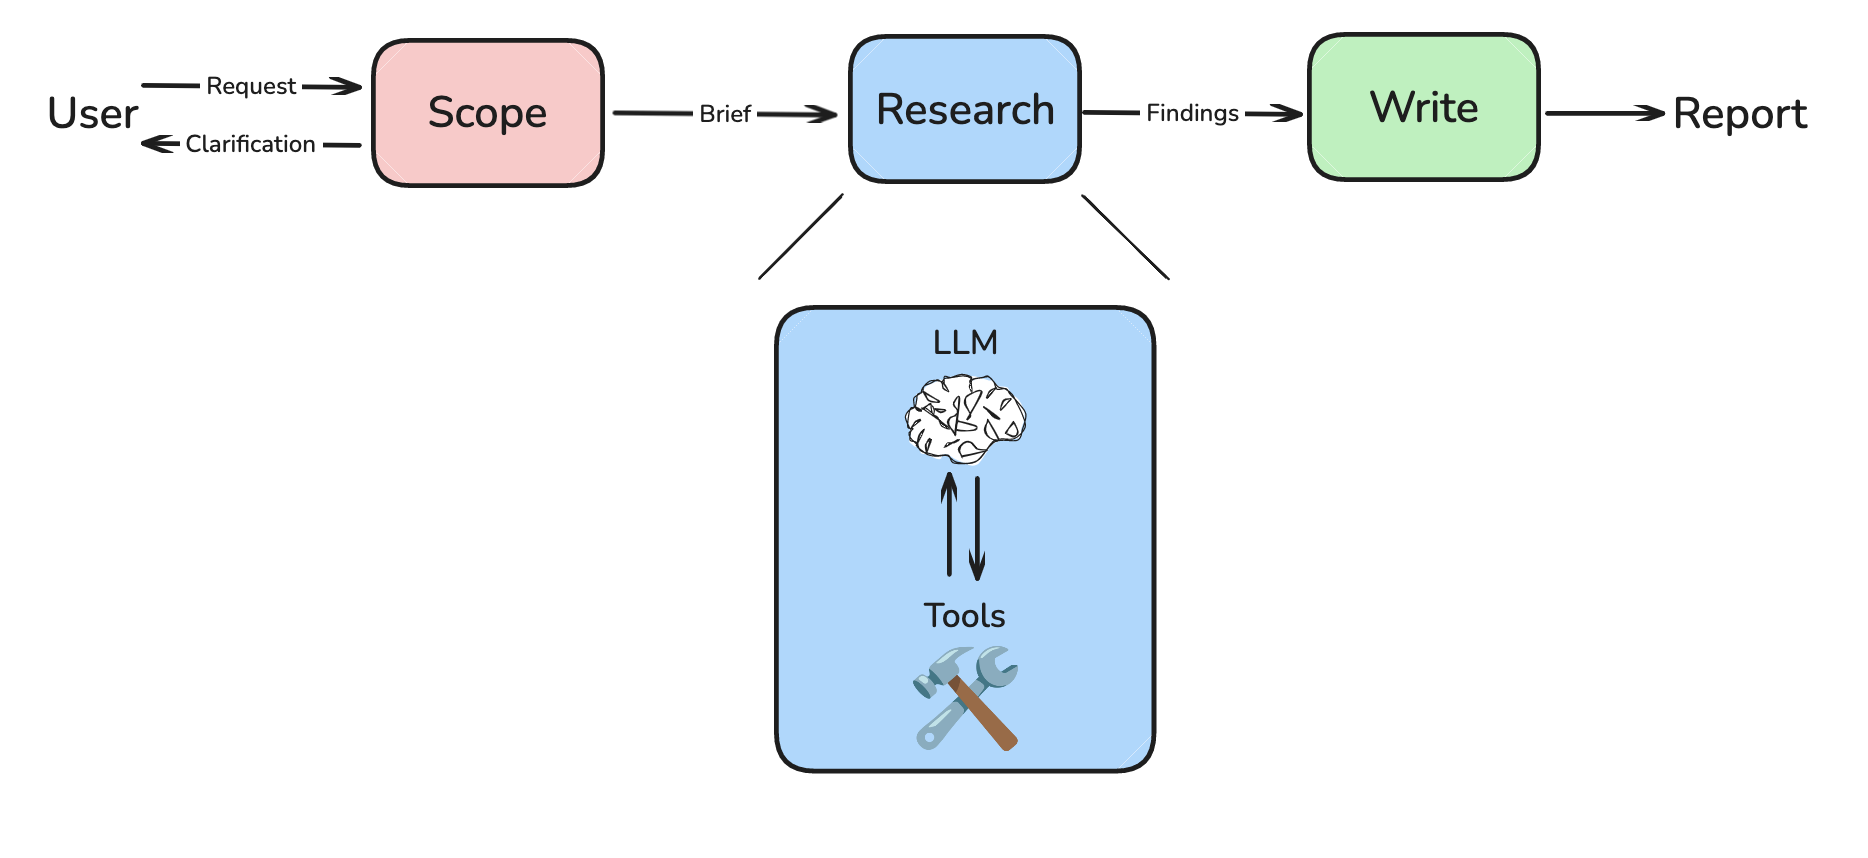

### 提示词

首先，我们将定义一个提示词，指导我们的智能体使用可用的搜索工具。

为了防止过度的工具调用并保持研究重点，我们使用[智能体的一些提示技术](https://youtu.be/XSZP9GhhuAc?si=zowpViL-2j-vI9hA)：

#### 1. 像智能体一样思考
你会给新同事什么指导？
- **仔细阅读问题** - 用户需要什么具体信息？
- **从更广泛的搜索开始** - 首先使用广泛、全面的查询
- **每次搜索后，暂停并评估** - 我有足够的信息来回答吗？还缺少什么？
- **随着收集信息执行更细致的搜索** - 填补空白。

#### 2. 具体的启发式方法（防止过度工具调用导致的"空转"）
使用**硬限制**来防止研究智能体过度调用工具：
- **当你能自信地回答时就停止** - 不要继续寻求完美。
- **给它预算** - 对简单查询使用2-3次搜索工具调用。对复杂查询使用最多5次。
- **限制** - 如果找不到正确的来源，在5次搜索工具调用后总是停止。

#### 3. 展示你的思考
在每次搜索工具调用后，使用[`think_tool`来分析结果](https://www.anthropic.com/engineering/claude-think-tool)：
- 我发现了什么关键信息？
- 还缺少什么？
- 我有足够的信息来全面回答问题吗？
- 我应该继续搜索还是提供答案？

#### 结果
这些技术将有问题的研究行为转换，比如：
```
"旧金山最佳咖啡店" → "Saint Frank Coffee详情" → "Sightglass Coffee详情" → "Ritual Coffee详情" → 等等（20+次搜索）
```

转换为高效模式，比如：
```
"旧金山最佳咖啡店" → ThinkTool(分析结果) → "旧金山特色咖啡质量评级" → ThinkTool(评估完整性) → 提供答案（总共3-5次搜索）
```

关键洞察：**像时间有限的人类研究员一样思考** - 这防止了智能体无限期继续搜索的"空转问题"。

In [2]:
from utils import show_prompt
from deep_research_from_scratch.prompts import research_agent_prompt
show_prompt(research_agent_prompt, "Research Agent Instructions")

╭────────────────────────────────────────── Research Agent Instructions ──────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research assistant conducting research on the user's input topic. For context, today's date is       │
│  {date}.                                                                                                        │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use tools to gather information about the user's input topic.                                   │
│  You can use any of the tools provided to you to find resources that can help answer the research question.     │
│  You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  You have access to two main tools:                                                                             │
│  1. **tavily_search**: For conducting web searches to gather information                                        │
│  2. **think_tool**: For reflection and strategic planning during research                                       │
│                                                                                                                 │
│  **CRITICAL: Use think_tool after each search to reflect on results and plan next steps**                       │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher with limited time. Follow these steps:                                           │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Start with broader searches** - Use broad, comprehensive queries first                                    │
│  3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?                 │
│  4. **Execute narrower searches as you gather information** - Fill in the gaps                                  │
│  5. **Stop when you can answer confidently** - Don't keep searching for perfection                              │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Tool Call Budgets** (Prevent excessive searching):                                                           │
│  - **Simple queries**: Use 2-3 search tool calls maximum                                                        │
│  - **Complex queries**: Use up to 5 search tool calls maximum                                                   │
│  - **Always stop**: After 5 search tool calls if you cannot find the right sources                              │
│                                                       

### 状态和模式

我们将创建智能体状态对象。

In [ ]:
%%writefile ../src/deep_research_from_scratch/state_research.py

"""
研究智能体的状态定义和Pydantic模式

此模块定义了研究智能体工作流使用的状态对象和结构化模式，
包括研究员状态管理和输出模式。
"""

import operator
from typing_extensions import TypedDict, Annotated, List, Sequence
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

# ===== 状态定义 =====

class ResearcherState(TypedDict):
    """
    研究智能体状态，包含消息历史和研究元数据。
    
    此状态跟踪研究员的对话、用于限制工具调用的迭代计数、
    正在调查的研究主题、压缩的发现和详细分析的原始研究笔记。
    """
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]
    tool_call_iterations: int
    research_topic: str
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]

class ResearcherOutputState(TypedDict):
    """
    研究智能体的输出状态，包含最终研究结果。
    
    这代表研究过程的最终输出，包含压缩的研究发现
    和研究过程中的所有原始笔记。
    """
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]

# ===== 结构化输出模式 =====

class ClarifyWithUser(BaseModel):
    """范围界定阶段用户澄清决策的模式。"""
    need_clarification: bool = Field(
        description="是否需要向用户询问澄清问题。",
    )
    question: str = Field(
        description="向用户询问以澄清报告范围的问题",
    )
    verification: str = Field(
        description="验证消息，确认在用户提供必要信息后我们将开始研究。",
    )

class ResearchQuestion(BaseModel):
    """研究概要生成的模式。"""
    research_brief: str = Field(
        description="将用于指导研究的研究问题。",
    )

class Summary(BaseModel):
    """网页内容摘要的模式。"""
    summary: str = Field(description="网页内容的简洁摘要")
    key_excerpts: str = Field(description="内容中的重要引言和摘录")

现在，我们将定义我们的研究工具。

#### Tavily SDK集成

我们将使用[Tavily SDK](https://docs.tavily.com/sdk/python/reference)来执行网络搜索。
 
Tavily是一个针对AI应用优化的搜索引擎，具有慷慨的免费额度，提供：
- 实时网络搜索结果
- 内容提取和摘要
- 域名过滤和结果排名
- 性能异步支持

#### 替代网络内容来源

虽然我们在本教程中使用Tavily的搜索API，但还有几个其他优秀的网络内容提取选项：

- **[Tavily Extract](https://docs.tavily.com/documentation/api-reference/endpoint/extract)**：Tavily的专用内容提取端点，可以从特定URL提取和清理内容，无需执行搜索
- **[Jina Reader](https://jina.ai/reader/)**：强大的网络内容提取服务，通过简单地在任何URL前添加`https://r.jina.ai/`，将网页转换为干净的、LLM友好的文本
- **[Firecrawl](https://www.firecrawl.dev/)**：综合的网络抓取平台，将网站转换为干净的markdown或结构化数据，具有JavaScript渲染和站点地图爬取等高级功能

每个工具都有不同的优势：Tavily在搜索优先的工作流程中表现出色，Jina Reader提供最简单的URL到文本转换，而Firecrawl为复杂站点提供最全面的网络抓取能力。

#### LangChain工具

我们将使用`@tool`装饰器将我们的Tavily搜索函数转换为[LangChain工具](https://python.langchain.com/docs/concepts/tools/)。这使能够：
- 为LLM自动生成模式
- 与LangChain的智能体框架集成
- 标准化的工具调用接口
- 类型验证和文档

请注意，一些参数被标注为[InjectedToolArg](https://python.langchain.com/api_reference/core/tools/langchain_core.tools.base.InjectedToolArg.html)。这些不包含在发送给LLM的工具模式中，而是在执行期间注入。这给了我们在运行时注入值的灵活性，但不会给语言模型带来管理这些参数的负担。

In [ ]:
%%writefile ../src/deep_research_from_scratch/utils.py

"""研究工具和实用程序。

此模块为研究智能体提供搜索和内容处理实用程序，
包括网络搜索功能和内容摘要工具。
"""

from pathlib import Path
from datetime import datetime
from typing_extensions import Annotated, List, Literal

from langchain.chat_models import init_chat_model 
from langchain_core.messages import HumanMessage
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import tool, InjectedToolArg
from tavily import TavilyClient

from deep_research_from_scratch.state_research import Summary
from deep_research_from_scratch.prompts import summarize_webpage_prompt

# ===== 实用函数 =====

def get_today_str() -> str:
    """获取人类可读格式的当前日期。"""
    return datetime.now().strftime("%a %b %-d, %Y")

def get_current_dir() -> Path:
    """获取模块的当前目录。

    此函数与Jupyter notebook和常规Python脚本兼容。

    Returns:
        表示当前目录的Path对象
    """
    try:
        return Path(__file__).resolve().parent
    except NameError:  # __file__未定义
        return Path.cwd()

# ===== 配置 =====

summarization_model = init_chat_model(model="openai:gpt-4.1-mini")
tavily_client = TavilyClient()

# ===== 搜索函数 =====

def tavily_search_multiple(
    search_queries: List[str], 
    max_results: int = 3, 
    topic: Literal["general", "news", "finance"] = "general", 
    include_raw_content: bool = True, 
) -> List[dict]:
    """使用Tavily API为多个查询执行搜索。

    Args:
        search_queries: 要执行的搜索查询列表
        max_results: 每个查询的最大结果数
        topic: 搜索结果的主题过滤器
        include_raw_content: 是否包含原始网页内容

    Returns:
        搜索结果字典列表
    """
    
    # 顺序执行搜索。注意：你可以使用AsyncTavilyClient来并行化这一步。
    search_docs = []
    for query in search_queries:
        result = tavily_client.search(
            query,
            max_results=max_results,
            include_raw_content=include_raw_content,
            topic=topic
        )
        search_docs.append(result)

    return search_docs

def summarize_webpage_content(webpage_content: str) -> str:
    """使用配置的摘要模型摘要网页内容。
    
    Args:
        webpage_content: 要摘要的原始网页内容
        
    Returns:
        带有关键摘录的格式化摘要
    """
    try:
        # 设置用于摘要的结构化输出模型
        structured_model = summarization_model.with_structured_output(Summary)
        
        # 生成摘要
        summary = structured_model.invoke([
            HumanMessage(content=summarize_webpage_prompt.format(
                webpage_content=webpage_content, 
                date=get_today_str()
            ))
        ])
        
        # 使用清晰结构格式化摘要
        formatted_summary = (
            f"<summary>\n{summary.summary}\n</summary>\n\n"
            f"<key_excerpts>\n{summary.key_excerpts}\n</key_excerpts>"
        )
        
        return formatted_summary
        
    except Exception as e:
        print(f"网页摘要失败：{str(e)}")
        return webpage_content[:1000] + "..." if len(webpage_content) > 1000 else webpage_content

def deduplicate_search_results(search_results: List[dict]) -> dict:
    """通过URL去重搜索结果，避免处理重复内容。
    
    Args:
        search_results: 搜索结果字典列表
        
    Returns:
        映射URL到唯一结果的字典
    """
    unique_results = {}
    
    for response in search_results:
        for result in response['results']:
            url = result['url']
            if url not in unique_results:
                unique_results[url] = result
    
    return unique_results

def process_search_results(unique_results: dict) -> dict:
    """通过在可用的地方摘要内容来处理搜索结果。
    
    Args:
        unique_results: 唯一搜索结果字典
        
    Returns:
        带有摘要的处理后结果字典
    """
    summarized_results = {}
    
    for url, result in unique_results.items():
        # 如果没有原始内容用于摘要，则使用现有内容
        if not result.get("raw_content"):
            content = result['content']
        else:
            # 摘要原始内容以便更好地处理
            content = summarize_webpage_content(result['raw_content'])
        
        summarized_results[url] = {
            'title': result['title'],
            'content': content
        }
    
    return summarized_results

def format_search_output(summarized_results: dict) -> str:
    """将搜索结果格式化为结构良好的字符串输出。
    
    Args:
        summarized_results: 处理后的搜索结果字典
        
    Returns:
        格式化的搜索结果字符串，具有清晰的来源分隔
    """
    if not summarized_results:
        return "没有找到有效的搜索结果。请尝试不同的搜索查询或使用不同的搜索API。"
    
    formatted_output = "搜索结果： \n\n"
    
    for i, (url, result) in enumerate(summarized_results.items(), 1):
        formatted_output += f"\n\n--- 来源 {i}: {result['title']} ---\n"
        formatted_output += f"URL: {url}\n\n"
        formatted_output += f"摘要：\n{result['content']}\n\n"
        formatted_output += "-" * 80 + "\n"
    
    return formatted_output

# ===== 研究工具 =====

@tool(parse_docstring=True)
def tavily_search(
    query: str,
    max_results: Annotated[int, InjectedToolArg] = 3,
    topic: Annotated[Literal["general", "news", "finance"], InjectedToolArg] = "general",
) -> str:
    """从Tavily搜索API获取结果并进行内容摘要。

    Args:
        query: 要执行的单个搜索查询
        max_results: 返回的最大结果数
        topic: 按主题过滤结果（'general'、'news'、'finance'）

    Returns:
        带有摘要的格式化搜索结果字符串
    """
    # 为单个查询执行搜索
    search_results = tavily_search_multiple(
        [query],  # 将单个查询转换为列表供内部函数使用
        max_results=max_results,
        topic=topic,
        include_raw_content=True,
    )

    # 通过URL去重结果，避免处理重复内容
    unique_results = deduplicate_search_results(search_results)

    # 使用摘要处理结果
    summarized_results = process_search_results(unique_results)

    # 格式化输出供使用
    return format_search_output(summarized_results)

@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """用于研究进展战略性反思和决策制定的工具。
    
    在每次搜索后使用此工具系统地分析结果并计划下一步。
    这在研究工作流程中创建了一个深思熟虑的暂停，以便做出高质量的决策。
    
    何时使用：
    - 收到搜索结果后：我发现了什么关键信息？
    - 决定下一步之前：我有足够的信息来全面回答吗？
    - 评估研究空白时：我仍然缺少什么具体信息？
    - 结束研究之前：我现在能提供完整的答案吗？
    
    反思应涉及：
    1. 当前发现的分析 - 我收集了什么具体信息？
    2. 空白评估 - 仍然缺少什么关键信息？
    3. 质量评估 - 我是否有足够的证据/例子来给出好的答案？
    4. 战略决策 - 我应该继续搜索还是提供答案？
    
    Args:
        reflection: 你对研究进展、发现、空白和下一步的详细反思
        
    Returns:
        确认反思已被记录用于决策制定
    """
    return f"反思已记录：{reflection}"

### 研究智能体

#### 概述

我们的研究智能体执行迭代工具调用来搜索信息。

智能体遵循一个[简单而有效的模式](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent)：

1. **LLM决策节点**：分析当前状态并决定是进行工具调用还是提供最终响应
2. **工具执行节点**：当LLM确定需要更多信息时执行搜索工具
3. **研究压缩节点**：总结和压缩研究发现以便高效处理
4. **路由逻辑**：根据LLM的决策确定工作流程的继续

#### 上下文工程策略

我们在两个地方应用**上下文工程**，遵循[智能体上下文工程](https://blog.langchain.com/context-engineering-for-agents/)中概述的原则：

#### 1. 网页内容摘要
原始搜索结果通常包含过多的噪音（导航、广告、样板内容）。我们的`summarize_webpage_content()`函数：
- 使用结构化输出提取关键信息和相关摘录
- 过滤无关内容，同时保留事实细节
- 将冗长的文章压缩为重点摘要
- 维护可信度的来源归属

#### 2. 研究结果压缩
随着智能体执行多次搜索，对话上下文迅速增长。我们的`compress_research()`函数：
- 将多次工具调用的发现合成为连贯的洞察
- 提取原始笔记进行详细分析，同时维护压缩摘要
- 减少后续LLM调用的令牌使用
- 为报告写作保留重要信息

这种双层上下文工程允许智能体高效处理大量信息，同时保持高质量的研究输出。

#### 3. 执行仔细的压缩
[压缩是有风险的](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus)！我们需要非常小心，不要丢失有价值的信息。我们将使用带有系统提示词中指令的LLM进行压缩，该提示词位于可能很长、令牌密集的多次工具调用轨迹之前。长上下文可能导致压缩LLM[失去对任务指令的关注](https://www.dbreunig.com/2025/06/22/how-contexts-fail-and-how-to-fix-them.html)，导致通用摘要而失去信息。因此，我们通过添加`compress_research_human_message`来强化压缩任务：
- 在压缩时明确重申原始研究主题
- 提醒模型保留与特定问题相关的所有信息
- 强调全面的发现对最终报告生成至关重要
- 防止压缩阶段的任务漂移

#### 4. 输出令牌管理
研究压缩可能生成长输出。我们需要确保它们不超过模型令牌限制，这可能导致截断响应，中途被切断（如看到"**Sextant Coffee Ro"被切断的情况）。例如，[GPT-4.1的输出限制高达33k令牌](https://openai.com/index/gpt-4-1/)，[Claude4 sonnet支持64k](https://www.anthropic.com/claude/sonnet)。

模型SDK / LangChain集成可能会限制这一点（例如，[在Claude的情况下限制为`1024`令牌](https://github.com/langchain-ai/langchain/blob/master/libs/partners/anthropic/langchain_anthropic/chat_models.py#L1149C5-L1149C15)）。只需确保设置最大令牌数以确保完整输出。这防止了不完整的压缩输出，并确保保留完整的研究发现。测试不同模型的压缩质量与延迟。例如：

* Claude4-Sonnet 99秒压缩延迟（[跟踪](https://smith.langchain.com/public/ca006e79-8838-47eb-9d8c-c7fe7d57a6bc/r)）
* GPT-4.1 38秒压缩延迟（[跟踪](https://smith.langchain.com/public/ca846b08-7501-43a0-bbda-735d4b07ab0a/r)）

In [ ]:
%%writefile ../src/deep_research_from_scratch/research_agent.py

"""研究智能体实现。

此模块实现了一个研究智能体，可以执行迭代网络搜索
和合成来回答复杂的研究问题。
"""

from pydantic import BaseModel, Field
from typing_extensions import Literal

from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage, filter_messages
from langchain.chat_models import init_chat_model

from deep_research_from_scratch.state_research import ResearcherState, ResearcherOutputState
from deep_research_from_scratch.utils import tavily_search, get_today_str, think_tool
from deep_research_from_scratch.prompts import research_agent_prompt, compress_research_system_prompt, compress_research_human_message

# ===== 配置 =====

# 设置工具和模型绑定
tools = [tavily_search, think_tool]
tools_by_name = {tool.name: tool for tool in tools}

# 初始化模型
model = init_chat_model(model="anthropic:claude-sonnet-4-20250514")
model_with_tools = model.bind_tools(tools)
summarization_model = init_chat_model(model="openai:gpt-4.1-mini")
compress_model = init_chat_model(model="openai:gpt-4.1", max_tokens=32000) # model="anthropic:claude-sonnet-4-20250514", max_tokens=64000

# ===== 智能体节点 =====

def llm_call(state: ResearcherState):
    """分析当前状态并决定下一步操作。
    
    模型分析当前对话状态并决定是否：
    1. 调用搜索工具收集更多信息
    2. 基于收集的信息提供最终答案
    
    返回带有模型响应的更新状态。
    """
    return {
        "researcher_messages": [
            model_with_tools.invoke(
                [SystemMessage(content=research_agent_prompt)] + state["researcher_messages"]
            )
        ]
    }

def tool_node(state: ResearcherState):
    """执行来自上一个LLM响应的所有工具调用。
    
    执行来自上一个LLM响应的所有工具调用。
    返回带有工具执行结果的更新状态。
    """
    tool_calls = state["researcher_messages"][-1].tool_calls
 
    # 执行所有工具调用
    observations = []
    for tool_call in tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observations.append(tool.invoke(tool_call["args"]))
            
    # 创建工具消息输出
    tool_outputs = [
        ToolMessage(
            content=observation,
            name=tool_call["name"],
            tool_call_id=tool_call["id"]
        ) for observation, tool_call in zip(observations, tool_calls)
    ]
    
    return {"researcher_messages": tool_outputs}

def compress_research(state: ResearcherState) -> dict:
    """将研究发现压缩为简洁摘要。
    
    获取所有研究消息和工具输出，创建一个
    适合监督者决策制定的压缩摘要。
    """
    
    system_message = compress_research_system_prompt.format(date=get_today_str())
    messages = [SystemMessage(content=system_message)] + state.get("researcher_messages", []) + [HumanMessage(content=compress_research_human_message)]
    response = compress_model.invoke(messages)
    
    # 从工具和AI消息中提取原始笔记
    raw_notes = [
        str(m.content) for m in filter_messages(
            state["researcher_messages"], 
            include_types=["tool", "ai"]
        )
    ]
    
    return {
        "compressed_research": str(response.content),
        "raw_notes": ["\n".join(raw_notes)]
    }

# ===== 路由逻辑 =====

def should_continue(state: ResearcherState) -> Literal["tool_node", "compress_research"]:
    """确定是继续研究还是提供最终答案。
    
    根据LLM是否进行工具调用，确定智能体应该
    继续研究循环还是提供最终答案。
    
    Returns:
        "tool_node": 继续到工具执行
        "compress_research": 停止并压缩研究
    """
    messages = state["researcher_messages"]
    last_message = messages[-1]
    
    # 如果LLM进行工具调用，继续到工具执行
    if last_message.tool_calls:
        return "tool_node"
    # 否则，我们有最终答案
    return "compress_research"

# ===== 图构建 =====

# 构建智能体工作流
agent_builder = StateGraph(ResearcherState, output_schema=ResearcherOutputState)

# 向图中添加节点
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)
agent_builder.add_node("compress_research", compress_research)

# 添加边来连接节点
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "tool_node": "tool_node", # 继续研究循环
        "compress_research": "compress_research", # 提供最终答案
    },
)
agent_builder.add_edge("tool_node", "llm_call") # 循环回去进行更多研究
agent_builder.add_edge("compress_research", END)

# 编译智能体
researcher_agent = agent_builder.compile()

In [ ]:
from IPython.display import Image, display
from deep_research_from_scratch.research_agent import researcher_agent

# 显示智能体
display(Image(researcher_agent.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
# 运行智能体
from utils import format_messages
from langchain_core.messages import HumanMessage

# 示例概要
research_brief = """我想要识别和评估旧金山被认为是最佳的咖啡店，特别是基于咖啡质量。我的研究应该专注于分析和比较旧金山地区内的咖啡店，将咖啡质量作为主要标准。我对评估咖啡质量的方法持开放态度（例如，专家评论、客户评级、特色咖啡认证），并且除非它们直接影响感知的咖啡质量，否则对氛围、位置、wifi或食物选择没有限制。请优先考虑主要来源，如咖啡店的官方网站、信誉良好的第三方咖啡评论组织（如Coffee Review或Specialty Coffee Association），以及像Google或Yelp这样的著名评论聚合器，在那里可以找到关于咖啡质量的直接客户反馈。研究应该产生一个有充分支持的旧金山顶级咖啡店列表或排名，根据截至2025年7月的最新可用数据，强调它们的咖啡质量。"""

result = researcher_agent.invoke({"researcher_messages": [HumanMessage(content=f"{research_brief}.")]})
format_messages(result['researcher_messages'])

In [12]:
from rich.markdown import Markdown
Markdown(result['compressed_research'])

List of Queries and Tool Calls Made                                                                                

 1 Query: best coffee shops San Francisco 2024 2025 coffee quality specialty coffee roasters reviews               
 2 Query: San Francisco coffee shops specialty coffee association awards Coffee Review ratings Saint Frank Sextant 
   Andytown                                                                                                        
 3 Query: "Saint Frank Coffee" "Sextant Coffee" "Andytown Coffee" San Francisco coffee quality reviews roasting    
   awards beans sourcing                                                                                           
 4 Query: Graffeo Coffee Roasting Company Andytown Coffee Sextant Coffee San Francisco customer reviews coffee     
   taste quality beans espresso                                                                                    

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Fully Comprehensive Findings                                                                                       

Best Coffee Roaster Near San Francisco, California:                                                                

 • Graffeo Coffee Roasting Company. 4.7 (196 reviews)                                                              
 • Andytown Coffee Roasters. 4.5 (1.1k reviews)                                                                    
   [1]                                                                                                             

San Francisco is globally renowned for its rich coffee culture, being the birthplace of influential coffee trends  
and establishments such as Wrecking Ball Coffee, which introduced the "waves of coffee" terminology. The city has  
embraced diverse coffee styles, notably Yemeni coffee promoted by figures like Mokhtar Alkhanshali of Port of Mokha
and Delah Coffee House. Traditional coffee culture landmarks include the origin of Irish Coffee and early Italian  
espresso influence. The latest list of the 16 best coffee shops in San Francisco reflects dynamic changes, with new
additions like Caffe Trieste, the Coffee Movement at Side A, and Cafe Shoji replacing others. These shops are      
celebrated for their expertly brewed coffee, unique beverages, and community-oriented atmospheres.                 

Highlighted coffee shops include:                                                                                  

 • Saint Frank Coffee: Known for its minimal aesthetic, high-quality Bolivian coffees, and expansion with new      
   locations including Juniper and SoMa.                                                                           
 • Outset Coffee: Innovators of fruit-infused coffee drinks like their Ethiopian coffee Americano with orange juice
   and jasmine tea.                                                                                                
 • Scullery: Specialty coffee serving East Bay’s Mother Tongue Coffee, offering quality fare in the Tenderloin     
   area.                                                                                                           
 • Sextant Coffee Roasters: Emphasizes direct relationships with Ethiopian, Kenyan, and Colombian growers, with    
   notable expansion.                                                                                              
 • Telescope Coffee: Offers creative seasonal drinks and a unique atmosphere in SoMa.                              
 • Abanico Coffee Roasters: A Latino-owned Mission District shop with Latin American coffee influences.            
 • SPRO - Mission Dolores/Castro: Creative coffee concoctions including a Cold Fashioned cold brew cocktail.       
 • Grand Coffee: Established 11 years ago with a second location, serving Mission Street with specialty brews.     
 • Hey Neighbor Cafe: Bayview’s cozy shop famed f

我们可以在[这里](https://smith.langchain.com/public/30eebc0c-455e-4db7-9665-d367ebd40b4e/r)看到追踪。

### LangGraph Studio

就像之前一样，我们也可以使用LangGraph Studio来可视化智能体。

这个智能体已经被添加到`langgraph.json`文件中，所以你可以在下拉菜单中选择`research_agent`：

```
"research_agent_mcp": "./src/deep_research_from_scratch/research_agent.py:agent"
```

运行以下命令启动studio

```bash
uvx --refresh --from "langgraph-cli[inmem]" --with-editable . --python 3.11 langgraph dev --allow-blocking
```

## 评估

智能体使用自主导向的工具调用轨迹来完成任务。

让我们思考一下调优不良的工具调用循环的后果：

- 提前终止：智能体决定在任务实际上尚未完成时停止调用工具。
- 长时间循环：智能体永远不满足其信息状态。

第一种失败模式导致智能体收集信息不足。在深度研究的背景下，答案可能最终过于浅显。第二种失败模式导致智能体使用过多的令牌。在深度研究的背景下，无关信息可能会污染结果。

我们调整了提示词来避免这些问题。但是，让我们建立一个玩具评估数据集，允许我们轻松测试智能体的决策制定。

In [ ]:
from langchain_core.messages import AIMessage, ToolMessage, HumanMessage

# 场景1：智能体应该继续 - 信息不足/无关信息 + think_tool意识到需要更多研究
messages_should_continue = [
    HumanMessage(content="基于咖啡质量，旧金山的顶级咖啡店有哪些？"),
    AIMessage(
        content="我将搜索关于旧金山顶级咖啡店的信息，重点关注咖啡质量。",
        tool_calls=[
            {
                "name": "tavily_search",
                "args": {
                    "query": "旧金山咖啡店热门地点"
                },
                "id": "call_continue_search_001",
                "type": "tool_call"
            }
        ]
    ),
    # Tavily搜索提供通用咖啡店信息 - 不专注于咖啡质量
    ToolMessage(
        content="搜索结果显示旧金山热门咖啡店：Blue Bottle Coffee有很棒的wifi和氛围，Philz Coffee以定制混合咖啡和友好服务著称，Café Reveille有多个地点，提供好的糕点和适合笔记本电脑的空间。Ritual Coffee提供舒适的座位，受学生欢迎。",
        tool_call_id="call_continue_search_001",
    ),
    # 智能体使用think_tool反思并意识到搜索结果不足
    AIMessage(
        content="让我使用think_tool来分析这些搜索结果并确定下一步。",
        tool_calls=[
            {
                "name": "think_tool",
                "args": {
                    "reflection": "搜索结果分析：我发现的信息主要关注一般咖啡店特征，如wifi、氛围、定制混合咖啡和座位 - 但缺乏具体的咖啡质量指标。用户明确要求基于咖啡质量的评估，这需要专家评论、专业评级、特色认证或以质量为重点的客户反馈。我需要专门搜索咖啡质量评估、Coffee Review评分、特色咖啡证书或旧金山咖啡店的专家评价。当前信息不足以回答用户关于咖啡质量的问题。"
                },
                "id": "call_continue_think_001",
                "type": "tool_call"
            }
        ]
    ),
    # think_tool响应识别差距和需要更有针对性研究的需要
    ToolMessage(
        content="反思已记录：搜索结果分析：我发现的信息主要关注一般咖啡店特征，如wifi、氛围、定制混合咖啡和座位 - 但缺乏具体的咖啡质量指标。用户明确要求基于咖啡质量的评估，这需要专家评论、专业评级、特色认证或以质量为重点的客户反馈。我需要专门搜索咖啡质量评估、Coffee Review评分、特色咖啡证书或旧金山咖啡店的专家评价。当前信息不足以回答用户关于咖啡质量的问题。",
        tool_call_id="call_continue_think_001",
    )
]

# 场景2：智能体应该停止 - 有全面的咖啡质量信息 + think_tool反思
messages_should_stop = [
    HumanMessage(content="基于咖啡质量，旧金山的顶级咖啡店有哪些？"),
    AIMessage(
        content="我将研究旧金山咖啡店，特别关注咖啡质量评估和专家评论。",
        tool_calls=[
            {
                "name": "tavily_search",
                "args": {
                    "query": "旧金山最佳咖啡质量特色咖啡专家评论Coffee Review评级2024"
                },
                "id": "call_stop_search_001", 
                "type": "tool_call"
            }
        ]
    ),
    # 这个ToolMessage提供全面的咖啡质量信息 - 足以回答问题
    ToolMessage(
        content="""旧金山咖啡质量研究显示基于专家评论和特色咖啡证书的顶级场所：

**顶级质量导向咖啡店：**
1. **Sightglass Coffee** - Coffee Review评分94/100，以单一产地豆和精确烘焙技术著称。被Bon Appétit的"美国最佳咖啡"列表收录，因出色的咖啡质量而入选。

2. **Saint Frank Coffee** - 被The Daily Meal根据咖啡质量排名为美国第3名咖啡店。Yelp评分4.3/5，评论特别赞扬"出色的豆类质量"和"完美萃取"。

3. **Ritual Coffee Roasters** - Specialty Coffee Association成员，直接贸易关系，Google评分持续4.4/5，评论强调"优质咖啡口味"和"专家咖啡师技能"。

4. **Blue Bottle Coffee** - 第三波咖啡先驱，Coffee Review评分平均90+/100，以严格的质量控制和新鲜烘焙做法著称。

5. **Four Barrel Coffee** - 本地烘焙商，Coffee Review评分88-92/100，被行业专家赞扬"出色的咖啡质量"和创新冲泡方法。

**发现的质量指标：**
- Coffee Review专业评分（88-94/100范围）
- Specialty Coffee Association认证
- 直接贸易/单一产地采购
- 食品出版物的专家认可
- 客户评论特别提到咖啡口味和质量

这提供了基于咖啡质量而非氛围或服务的旧金山咖啡店的全面评估。""",
        tool_call_id="call_stop_search_001",
    ),
    # 智能体现在使用think_tool反思搜索结果
    AIMessage(
        content="让我使用think_tool反思搜索结果，评估我是否有足够的信息。",
        tool_calls=[
            {
                "name": "think_tool",
                "args": {
                    "reflection": "搜索结果分析：我发现了旧金山咖啡店的全面咖啡质量信息，包括：1）专业Coffee Review评分（88-94/100），2）权威出版物的专家排名，3）Specialty Coffee Association认证，4）具体质量指标（单一产地、烘焙技术、萃取方法），5）五个顶级场所的详细质量评估。这涵盖了所有要求的方面：专家评论、客户评级、特色认证。我有足够的信息来提供基于咖啡质量的有充分支持的排名。不需要额外搜索 - 我现在应该提供全面的答案。"
                },
                "id": "call_think_001",
                "type": "tool_call"
            }
        ]
    ),
    # think_tool响应确认反思已记录
    ToolMessage(
        content="反思已记录：搜索结果分析：我发现了旧金山咖啡店的全面咖啡质量信息，包括：1）专业Coffee Review评分（88-94/100），2）权威出版物的专家排名，3）Specialty Coffee Association认证，4）具体质量指标（单一产地、烘焙技术、萃取方法），5）五个顶级场所的详细质量评估。这涵盖了所有要求的方面：专家评论、客户评级、特色认证。我有足够的信息来提供基于咖啡质量的有充分支持的排名。不需要额外搜索 - 我现在应该提供全面的答案。",
        tool_call_id="call_think_001",
    )
]

我们将在这里创建一个数据集，其中有一个应该继续研究的示例，另一个应该具有所有必要信息的示例。

In [ ]:
import os
from langsmith import Client

langsmith_client = Client(api_key=os.getenv("LANGSMITH_API_KEY"))

# 创建数据集
dataset_name = "deep_research_agent_termination"
if not langsmith_client.has_dataset(dataset_name=dataset_name):

    # 创建数据集
    dataset = langsmith_client.create_dataset(
        dataset_name=dataset_name,
        description="评估研究员是否能准确决定继续调用工具或停止的数据集。",
    )
    
    # 创建示例
    langsmith_client.create_examples(
        dataset_id=dataset.id,
        examples=[
            {
                "inputs": {"researcher_messages": messages_should_continue},
                "outputs": {"next_step": "continue"},
            },
            {
                "inputs": {"researcher_messages": messages_should_stop},
                "outputs": {"next_step": "stop"},
            },
        ],
    )

这里，我们的评估器很简单，使用硬编码的启发式方法来检查智能体是否正确地继续或停止。

我们将传入上面的消息列表。

我们将评估智能体做出的决策：

* `stop` - 无工具调用意味着智能体应该停止
* `continue` - 工具调用意味着智能体应该继续

然后我们将这个决策与参考期望决策`next_step`进行比较。

In [ ]:
import uuid

def evaluate_next_step(outputs: dict, reference_outputs:dict):
    tool_calls = outputs["researcher_messages"][-1].tool_calls
    made_tool_call = len(tool_calls) > 0
    return {
        "key": "correct_next_step",
        "score": made_tool_call == (reference_outputs["next_step"] == "continue")
    }

def target_func(inputs: dict):
    config = {"configurable": {"thread_id": uuid.uuid4()}}
    result = researcher_agent.nodes["llm_call"].invoke(inputs, config=config)
    return result

langsmith_client.evaluate(
    target_func,
    data=dataset_name,
    evaluators=[evaluate_next_step],
    experiment_prefix="研究员迭代",
)

我们可以看到在一个示例中，搜索工具没有返回足够的信息，所以我们通过工具调用提交另一个搜索。

在另一个示例中，我们得到了所有三家顶级餐厅的信息，所以我们决定结束。

这里有一个巧妙的技巧 - 我们能够通过调用`agent.nodes["node_name].invoke`来测试图的单个节点